In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("../datasets/Finance_habit_dataset.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (20000, 27)


In [3]:
df.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Income                           20000 non-null  float64
 1   Age                              20000 non-null  int64  
 2   Dependents                       20000 non-null  int64  
 3   Occupation                       20000 non-null  object 
 4   City_Tier                        20000 non-null  object 
 5   Rent                             20000 non-null  float64
 6   Loan_Repayment                   20000 non-null  float64
 7   Insurance                        20000 non-null  float64
 8   Groceries                        20000 non-null  float64
 9   Transport                        20000 non-null  float64
 10  Eating_Out                       20000 non-null  float64
 11  Entertainment                    20000 non-null  float64
 12  Utilities         

In [5]:
df.isnull().sum()

Income                             0
Age                                0
Dependents                         0
Occupation                         0
City_Tier                          0
Rent                               0
Loan_Repayment                     0
Insurance                          0
Groceries                          0
Transport                          0
Eating_Out                         0
Entertainment                      0
Utilities                          0
Healthcare                         0
Education                          0
Miscellaneous                      0
Desired_Savings_Percentage         0
Desired_Savings                    0
Disposable_Income                  0
Potential_Savings_Groceries        0
Potential_Savings_Transport        0
Potential_Savings_Eating_Out       0
Potential_Savings_Entertainment    0
Potential_Savings_Utilities        0
Potential_Savings_Healthcare       0
Potential_Savings_Education        0
Potential_Savings_Miscellaneous    0
d

In [6]:
df.describe()

,Income,Age,Dependents,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
count,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,4.158550e+04,41.031450,1.995950,9115.494629,2049.800292,1455.028761,5205.667493,2704.466685,1461.856982,1448.853658,...,4982.878416,10647.367257,912.197183,473.042650,254.963280,254.031058,436.332808,41.524964,62.417083,144.904987
std,4.001454e+04,13.578725,1.417616,9254.228188,4281.789941,1492.938435,5035.953689,2666.345648,1481.660811,1489.019270,...,7733.468188,11740.637289,1038.884968,537.222853,296.047943,299.973590,503.200658,53.152458,98.842656,169.160951
min,1.301187e+03,18.000000,0.000000,235.365692,0.000000,30.002012,154.078240,81.228584,39.437523,45.421469,...,0.000000,-5400.788673,16.575501,8.268076,3.797926,3.121610,6.200297,0.001238,0.000000,2.091973
25%,1.760488e+04,29.000000,1.000000,3649.422246,0.000000,580.204749,2165.426419,1124.578012,581.011801,581.632906,...,1224.932636,3774.894323,317.811000,161.913751,84.506870,84.562090,148.013618,11.037421,4.926210,47.637307
50%,3.018538e+04,41.000000,2.000000,6402.751824,0.000000,1017.124681,3741.091535,1933.845509,1029.109726,1020.198376,...,2155.356763,7224.890977,607.038735,307.045856,164.927660,164.740232,285.739582,25.202124,33.127987,93.090257
75%,5.176545e+04,53.000000,3.000000,11263.940492,2627.142320,1787.160895,6470.892718,3360.597508,1807.075251,1790.104082,...,6216.309609,13331.950716,1128.681837,588.419602,313.398240,310.927935,538.983703,52.353736,80.946145,178.257981
max,1.079728e+06,64.000000,4.000000,215945.674703,123080.682009,38734.932935,119816.898124,81861.503457,34406.100166,38667.368308,...,245504.485208,377060.218482,34894.644404,12273.258242,5573.036433,6222.200913,8081.799518,1394.531049,3647.244243,4637.951137


In [7]:
df["Total_Expenses"] = (
    df["Rent"]
    + df["Loan_Repayment"]
    + df["Insurance"]
    + df["Groceries"]
    + df["Transport"]
    + df["Eating_Out"]
    + df["Entertainment"]
    + df["Utilities"]
    + df["Healthcare"]
    + df["Education"]
    + df["Miscellaneous"]
)

df["Actual_Savings"] = df["Income"] - df["Total_Expenses"]

df["Savings_Rate"] = (
    df["Actual_Savings"] / df["Income"]
) * 100

df["Loan_Ratio"] = (
    df["Loan_Repayment"] / df["Income"]
) * 100

print(df[[
    "Income",
    "Total_Expenses",
    "Actual_Savings",
    "Savings_Rate",
    "Loan_Ratio"
]].head())

          Income  Total_Expenses  Actual_Savings  Savings_Rate  Loan_Ratio
0   44637.249636    33371.621929    11265.627707     25.238176    0.000000
1   26858.596592    17181.777859     9676.818733     36.028758    0.000000
2   50367.605084    36476.154459    13891.450624     27.580129    9.156884
3  101455.600247    69837.646632    31617.953615     31.164326    6.711745
4   24875.283548    18609.583016     6265.700532     25.188459   12.512860


In [8]:
df[[
    "Actual_Savings",
    "Savings_Rate",
    "Loan_Ratio"
]].describe()

,Actual_Savings,Savings_Rate,Loan_Ratio
count,20000.000000,20000.000000,20000.000000
mean,10647.367257,25.512167,4.990485
std,11740.637289,9.718970,6.712981
min,-5400.788673,-6.237779,0.000000
25%,3774.894323,18.970791,0.000000
50%,7224.890977,26.488739,0.000000
75%,13331.950716,32.767579,10.632810
max,377060.218482,50.650369,19.993827


In [9]:
print("Negative savings:", (df["Actual_Savings"] < 0).sum())
print("Average savings rate:", df["Savings_Rate"].mean())
print("Average loan ratio:", df["Loan_Ratio"].mean())

Negative savings: 112
Average savings rate: 25.512166954571843
Average loan ratio: 4.990485387062795


In [10]:
df.shape

(20000, 31)

In [11]:
# Expense burden as percentage of income
df["Expense_Ratio"] = (
    df["Total_Expenses"] / df["Income"]
) * 100

# ------------------------------------------------
# 1. Savings Score (0-40)
# ------------------------------------------------
df["Savings_Score"] = (
    df["Savings_Rate"].clip(0, 40) / 40
) * 40


# ------------------------------------------------
# 2. Debt Score (0-30)
# Lower loan ratio = better
# ------------------------------------------------
df["Debt_Score"] = (
    1 - (df["Loan_Ratio"].clip(0, 20) / 20)
) * 30


# ------------------------------------------------
# 3. Expense Score (0-30)
# Lower expense ratio = better
# ------------------------------------------------
df["Expense_Score"] = (
    1 - (df["Expense_Ratio"].clip(0, 100) / 100)
) * 30


# ------------------------------------------------
# Final Financial Health Score
# ------------------------------------------------
df["Financial_Health_Score"] = (
    df["Savings_Score"]
    + df["Debt_Score"]
    + df["Expense_Score"]
)

# Keep score between 0 and 100
df["Financial_Health_Score"] = (
    df["Financial_Health_Score"].clip(0, 100)
)

df[
    [
        "Income",
        "Savings_Rate",
        "Loan_Ratio",
        "Expense_Ratio",
        "Financial_Health_Score"
    ]
].head()

,Income,Savings_Rate,Loan_Ratio,Expense_Ratio,Financial_Health_Score
0,44637.249636,25.238176,0.000000,74.761824,62.809629
1,26858.596592,36.028758,0.000000,63.971242,76.837385
2,50367.605084,27.580129,9.156884,72.419871,52.118841
3,101455.600247,31.164326,6.711745,68.835674,60.446005
4,24875.283548,25.188459,12.512860,74.811541,43.975706


In [12]:
df["Financial_Health_Score"].describe()

count    20000.000000
mean        55.563341
std         20.702923
min          0.055183
25%         40.146020
50%         60.585879
75%         72.124565
max         85.195111
Name: Financial_Health_Score, dtype: float64

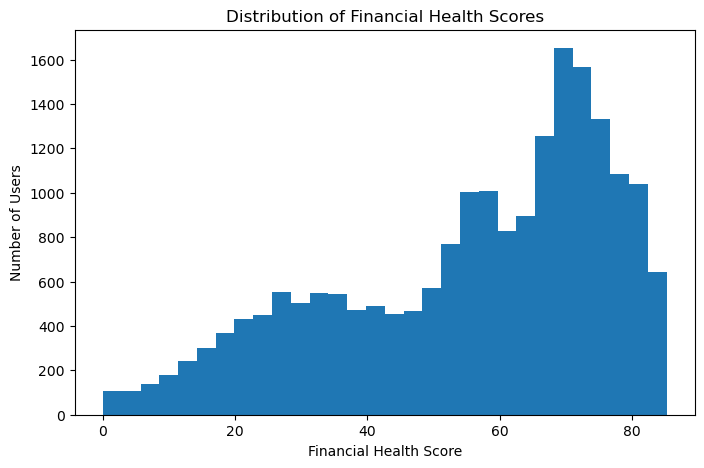

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(df["Financial_Health_Score"], bins=30)

plt.xlabel("Financial Health Score")
plt.ylabel("Number of Users")
plt.title("Distribution of Financial Health Scores")

plt.show()

In [14]:
def health_category(score):
    if score < 40:
        return "Poor"
    elif score < 70:
        return "Average"
    else:
        return "Good"


df["Financial_Health"] = df["Financial_Health_Score"].apply(
    health_category
)

print(df["Financial_Health"].value_counts())

Financial_Health
Average    8798
Good       6221
Poor       4981
Name: count, dtype: int64


In [15]:
print(
    df[
        [
            "Financial_Health_Score",
            "Financial_Health"
        ]
    ].head(20)
)

    Financial_Health_Score Financial_Health
0                62.809629          Average
1                76.837385             Good
2                52.118841          Average
3                60.446005          Average
4                43.975706          Average
5                69.713779          Average
6                80.955597             Good
7                27.373642             Poor
8                 6.357533             Poor
9                74.050158             Good
10               80.592710             Good
11               68.490809          Average
12               27.508008             Poor
13               67.664784          Average
14               67.227697          Average
15               31.973386             Poor
16               12.139802             Poor
17               65.765330          Average
18               43.668849          Average
19               79.076905             Good


In [16]:
# Features used by the ML model
features = [
    "Income",
    "Age",
    "Dependents",
    "Occupation",
    "City_Tier",
    "Rent",
    "Loan_Repayment",
    "Insurance",
    "Groceries",
    "Transport",
    "Eating_Out",
    "Entertainment",
    "Utilities",
    "Healthcare",
    "Education",
    "Miscellaneous",
    "Desired_Savings_Percentage",
    "Desired_Savings"
]

X = df[features]
y = df["Financial_Health"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

X shape: (20000, 18)
y shape: (20000,)

Features:
['Income', 'Age', 'Dependents', 'Occupation', 'City_Tier', 'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education', 'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings']

Target distribution:
Financial_Health
Average    8798
Good       6221
Poor       4981
Name: count, dtype: int64


In [17]:
categorical_features = [
    "Occupation",
    "City_Tier"
]

numerical_features = [
    "Income",
    "Age",
    "Dependents",
    "Rent",
    "Loan_Repayment",
    "Insurance",
    "Groceries",
    "Transport",
    "Eating_Out",
    "Entertainment",
    "Utilities",
    "Healthcare",
    "Education",
    "Miscellaneous",
    "Desired_Savings_Percentage",
    "Desired_Savings"
]

print("Categorical features:", categorical_features)
print("Numerical features:", len(numerical_features))

Categorical features: ['Occupation', 'City_Tier']
Numerical features: 16


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training samples: 16000
Testing samples: 4000

Training distribution:
Financial_Health
Average    7038
Good       4977
Poor       3985
Name: count, dtype: int64

Testing distribution:
Financial_Health
Average    1760
Good       1244
Poor        996
Name: count, dtype: int64


In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully")

Preprocessor created successfully


In [20]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20000, 18)
y shape: (20000,)


In [21]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.2.0


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# L2 Logistic Regression
logistic_l2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=2000,
        random_state=42
    ))
])

# L1 Logistic Regression
logistic_l1 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        penalty="l1",
        C=1.0,
        solver="liblinear",
        max_iter=2000,
        random_state=42
    ))
])

print("Logistic Regression pipelines created.")

Logistic Regression pipelines created.


In [23]:
print("Training L2 Logistic Regression...")

logistic_l2.fit(X_train, y_train)

print("L2 training completed.")

print("\nTraining L1 Logistic Regression...")

logistic_l1.fit(X_train, y_train)

print("L1 training completed.")

Training L2 Logistic Regression...
L2 training completed.

Training L1 Logistic Regression...


C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


L1 training completed.


In [24]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

def evaluate_model(name, model):
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return accuracy, macro_f1


l2_accuracy, l2_f1 = evaluate_model(
    "Logistic Regression - L2",
    logistic_l2
)

l1_accuracy, l1_f1 = evaluate_model(
    "Logistic Regression - L1",
    logistic_l1
)

Logistic Regression - L2
Accuracy : 0.9395
Macro F1 : 0.9408

Classification Report:
              precision    recall  f1-score   support

     Average       0.94      0.92      0.93      1760
        Good       0.93      0.97      0.95      1244
        Poor       0.95      0.93      0.94       996

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.94      0.94      0.94      4000

Confusion Matrix:
[[1624   89   47]
 [  38 1206    0]
 [  68    0  928]]
Logistic Regression - L1
Accuracy : 0.9825
Macro F1 : 0.9827

Classification Report:
              precision    recall  f1-score   support

     Average       0.99      0.97      0.98      1760
        Good       0.98      0.99      0.99      1244
        Poor       0.97      0.99      0.98       996

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

C_values = [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]

results = []

for C in C_values:

    print(f"Training L1 Logistic Regression with C={C}...")

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            penalty="l1",
            C=C,
            solver="saga",
            max_iter=3000,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    results.append({
        "C": C,
        "Accuracy": accuracy,
        "Macro_F1": macro_f1
    })

results_df = pd.DataFrame(results)

print("\nTuning Results:")
print(results_df)

Training L1 Logistic Regression with C=0.01...
Training L1 Logistic Regression with C=0.05...


C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training L1 Logistic Regression with C=0.1...


C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training L1 Logistic Regression with C=0.5...


...

C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training L1 Logistic Regression with C=5...


C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training L1 Logistic Regression with C=10...

Tuning Results:
       C  Accuracy  Macro_F1
0   0.01   0.82050  0.827881
1   0.05   0.91700  0.919306
2   0.10   0.93400  0.935286
3   0.50   0.93975  0.940848
4   1.00   0.94100  0.942058
5   2.00   0.94175  0.942773
6   5.00   0.94200  0.943041
7  10.00   0.94225  0.943268


C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [27]:
best_result = results_df.loc[
    results_df["Macro_F1"].idxmax()
]

print("\nBest Configuration:")
print(best_result)


Best Configuration:
C           10.000000
Accuracy     0.942250
Macro_F1     0.943268
Name: 7, dtype: float64


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

l1_tuned = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        penalty="l1",
        C=10,
        solver="saga",
        max_iter=10000,
        tol=1e-4,
        random_state=42
    ))
])

print("Training final L1 model...")

l1_tuned.fit(X_train, y_train)

print("Training completed successfully.")

Training final L1 model...
Training completed successfully.


In [29]:
model_step = l1_tuned.named_steps["model"]

print("Number of iterations used:")
print(model_step.n_iter_)

Number of iterations used:
[5668]


In [30]:
y_pred = l1_tuned.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print("=" * 60)
print("Tuned L1 Logistic Regression")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")

Tuned L1 Logistic Regression
Accuracy : 0.9575
Macro F1 : 0.9585


In [31]:
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

     Average       0.96      0.95      0.95      1760
        Good       0.95      0.98      0.96      1244
        Poor       0.97      0.95      0.96       996

    accuracy                           0.96      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.96      0.96      0.96      4000


Confusion Matrix:
[[1666   63   31]
 [  30 1214    0]
 [  46    0  950]]


In [32]:
print("Iterations used:", model_step.n_iter_)

Iterations used: [5668]


In [33]:
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

print("Training Random Forest...")

random_forest.fit(X_train, y_train)

print("Random Forest training completed.")

Training Random Forest...
Random Forest training completed.


In [34]:
y_pred_rf = random_forest.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="macro"
)

print("=" * 60)
print("Random Forest")
print("=" * 60)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Macro F1 : {rf_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy : 0.9008
Macro F1 : 0.9038

Classification Report:
              precision    recall  f1-score   support

     Average       0.88      0.89      0.89      1760
        Good       0.91      0.90      0.90      1244
        Poor       0.92      0.92      0.92       996

    accuracy                           0.90      4000
   macro avg       0.90      0.90      0.90      4000
weighted avg       0.90      0.90      0.90      4000



In [35]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.2.0


In [36]:
from xgboost import XGBClassifier

# Convert target labels to numbers
label_map = {
    "Poor": 0,
    "Average": 1,
    "Good": 2
}

y_train_xgb = y_train.map(label_map)
y_test_xgb = y_test.map(label_map)

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ))
])

print("Training XGBoost...")

xgb_model.fit(X_train, y_train_xgb)

print("XGBoost training completed.")

Training XGBoost...
XGBoost training completed.


In [37]:
y_pred_xgb = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(
    y_test_xgb,
    y_pred_xgb
)

xgb_f1 = f1_score(
    y_test_xgb,
    y_pred_xgb,
    average="macro"
)

print("=" * 60)
print("XGBoost")
print("=" * 60)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Macro F1 : {xgb_f1:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test_xgb,
        y_pred_xgb,
        target_names=["Poor", "Average", "Good"]
    )
)

XGBoost
Accuracy : 0.9067
Macro F1 : 0.9102

Classification Report:
              precision    recall  f1-score   support

        Poor       0.92      0.94      0.93       996
     Average       0.90      0.88      0.89      1760
        Good       0.90      0.92      0.91      1244

    accuracy                           0.91      4000
   macro avg       0.91      0.91      0.91      4000
weighted avg       0.91      0.91      0.91      4000



In [38]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Running 5-fold cross-validation...")

cv_scores = cross_val_score(
    l1_tuned,
    X,
    y,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("\nCross-validation Macro F1 scores:")
print(cv_scores)

print("\nMean Macro F1:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Running 5-fold cross-validation...

Cross-validation Macro F1 scores:
[0.96036078 0.95687227 0.95480539 0.97105481 0.95433626]

Mean Macro F1: 0.9594859011781974
Standard Deviation: 0.006162174393353551


In [39]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        penalty="l1",
        C=10,
        solver="saga",
        max_iter=10000,
        tol=1e-4,
        random_state=42
    ))
])

print("Training final model on all 20,000 records...")

final_model.fit(X, y)

print("Final model training completed.")

Training final model on all 20,000 records...
Final model training completed.


In [40]:
sample_data = X.sample(10, random_state=42)

sample_predictions = final_model.predict(sample_data)

sample_results = sample_data.copy()

sample_results["Predicted_Health"] = sample_predictions

sample_results

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Desired_Savings_Percentage,Desired_Savings,Predicted_Health
10650,25170.370398,23,4,Retired,Tier_2,5034.074080,0.000000,571.826422,3124.233037,2002.825335,758.940472,815.723681,1947.475600,951.120259,1994.412171,486.505275,6.268935,1577.914091,Average
2041,21623.299874,48,1,Self_Employed,Tier_2,4324.659975,0.000000,468.588277,2549.652415,1454.719436,813.946784,947.011991,1045.794103,756.767694,1451.141708,376.743996,9.121335,1972.333691,Good
8668,40819.932938,30,2,Retired,Tier_2,8163.986588,4492.850514,1202.675988,6060.606479,3013.018468,1278.091388,1736.638415,2735.204249,1705.296346,2325.220643,615.907838,10.215035,4169.770337,Poor
1114,33836.242989,37,4,Retired,Tier_2,6767.248598,2446.775991,1314.658328,4924.689606,1691.818821,1333.902755,1503.010364,2290.298683,1335.736970,2818.323229,866.343884,8.281445,2802.129842,Average
13902,28898.734885,22,2,Student,Tier_2,5779.746977,0.000000,697.131090,3498.144912,2168.369080,603.538061,1029.325587,2191.883560,1257.877245,1741.007052,359.289239,9.710663,2806.258857,Good
11963,13587.991307,41,1,Professional,Tier_1,4076.397392,0.000000,444.189345,1491.092772,965.869965,462.830133,374.353493,700.354461,487.953678,1185.628123,329.278660,8.852478,1202.874008,Average
11072,12293.815998,41,1,Self_Employed,Tier_2,2458.763200,0.000000,271.785817,1443.517222,866.568390,387.902023,599.738814,529.976017,613.314143,830.645578,329.365282,6.526150,802.312923,Good
3002,21548.645375,62,4,Self_Employed,Tier_2,4309.729075,4284.721224,635.129003,3036.614116,1101.470035,571.192135,1002.354115,1450.072364,1034.173901,2024.063962,402.440259,6.555304,1412.579268,Poor
19771,18849.071208,21,4,Retired,Tier_2,3769.814242,974.347893,548.286592,2672.798843,1403.437186,535.726801,741.779383,828.829669,596.758669,1468.876121,399.149978,5.500857,1036.860511,Average
8115,26400.912746,18,2,Professional,Tier_3,3960.136912,0.000000,610.788127,3652.904538,1540.514854,748.592757,545.628350,1127.741662,1156.401746,2555.249195,273.244918,6.000658,1584.228375,Good


In [45]:
sample_probabilities = final_model.predict_proba(sample_data)

probability_df = pd.DataFrame(
    sample_probabilities,
    columns=final_model.named_steps["model"].classes_
)

probability_df

,Average,Good,Poor
0,0.666303,3.336474e-01,4.976559e-05
1,0.114525,8.854617e-01,1.311876e-05
2,0.409530,1.342940e-12,5.904705e-01
3,0.876518,2.924656e-08,1.234823e-01
4,0.168095,8.319041e-01,6.196598e-07
5,0.952120,1.236316e-02,3.551680e-02
6,0.290223,7.085822e-01,1.194261e-03
7,0.000256,1.846493e-15,9.997440e-01
8,0.977258,4.313574e-03,1.842824e-02
9,0.003856,9.961437e-01,6.310381e-09


In [42]:
import os
import joblib

model_path = "../models/financial_health_model.pkl"

os.makedirs("../models", exist_ok=True)

joblib.dump(final_model, model_path)

print("Model saved successfully:")
print(model_path)

Model saved successfully:
../models/financial_health_model.pkl


In [43]:
import os

print(os.path.exists(model_path))
print(os.path.getsize(model_path), "bytes")

True
5169 bytes
